In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from scipy import stats
import time

In [53]:
# Load data
data = pd.read_csv('diabetes.csv')

# Preview data
print('Dataframe shape:', data.shape)
data.head(3)

Dataframe shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [54]:
data.drop(columns=['Outcome', 'Pregnancies'], inplace=True)

In [55]:
from sklearn.preprocessing import StandardScaler
numerical_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])
data.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,50
1,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,31
2,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,32
3,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,21
4,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,33


In [56]:
# Features and labels
X = data.drop('Age', axis=1)
y = data['Age']

In [57]:
# Split dataset into training and testing data (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [58]:
class kNN():
    '''k-Nearest Neighbours'''
    # Initialise
    def __init__(self, k=3, metric='euclidean', p=None):
        self.k = k
        self.metric = metric
        self.p = p

    # Euclidean distance (l2 norm)
    def euclidean(self, v1, v2):
        return np.sqrt(np.sum((v1-v2)**2))

    # Manhattan distance (l1 norm)
    def manhattan(self, v1, v2):
        return np.sum(np.abs(v1-v2))

    # Minkowski distance (lp norm)
    def minkowski(self, v1, v2, p=2):
        return np.sum(np.abs(v1-v2)**p)**(1/p)

    # Store train set
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    # Make predictions
    def predict(self, X_test):
        preds = []
        # Loop over rows in test set
        for test_row in X_test:
            nearest_neighbours = self.get_neighbours(test_row)
            majority = stats.mode(nearest_neighbours, axis=None).mode[0]
            preds.append(majority)
        return np.array(preds)

    # Get nearest neighbours
    def get_neighbours(self, test_row):
        distances = list()

        # Calculate distance to all points in X_train
        for (train_row, train_class) in zip(self.X_train, self.y_train):
            if self.metric=='euclidean':
                dist = self.euclidean(train_row, test_row)
            elif self.metric=='manhattan':
                dist = self.manhattan(train_row, test_row)
            elif self.metric=='minkowski':
                dist = self.minkowski(train_row, test_row, self.p)
            else:
                raise NameError('Supported metrics are euclidean, manhattan and minkowski')
            distances.append((dist, train_class))

        # Sort distances
        distances.sort(key=lambda x: x[0])

        # Identify k nearest neighbours
        neighbours = list()
        for i in range(self.k):
            neighbours.append(distances[i][1])

        return neighbours

In [59]:
# Function to calculate accuracy
def accuracy(preds, y_test):
    return 100 * (preds == y_test).mean()

# Apply our kNN algorithm
for metric in ['euclidean', 'manhattan']:
    clf = kNN(k=5, metric=metric)
    clf.fit(X_train.values, y_train.values)
    preds = clf.predict(X_test.values)
    print(f'Metric: {metric}, accuracy: {accuracy(preds, y_test):.3f} %')

Metric: euclidean, accuracy: 5.844 %
Metric: manhattan, accuracy: 7.143 %


C:\Users\minhk\AppData\Local\Temp\ipykernel_30544\4103998404.py:32: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  majority = stats.mode(nearest_neighbours, axis=None).mode[0]


In [60]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train.values, y_train.values)
preds = clf.predict(X_test.values)

# Calculate test set accuracy
def accuracy(preds, y_test):
    return 100 * (preds == y_test).mean()
print(f'Sklearn accuracy: {accuracy(preds, y_test):.3f} %')

Sklearn accuracy: 5.844 %


In [61]:
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(X_train.values, y_train.values)
preds = clf.predict(X_test.values)

# Calculate test set accuracy
def accuracy(preds, y_test):
    return 100 * (preds == y_test).mean()
print(f'Navie bayes accuracy: {accuracy(preds, y_test):.3f} %')

Navie bayes accuracy: 3.896 %


In [62]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train.values, y_train.values)
preds = clf.predict(X_test.values)

# Calculate test set accuracy
def accuracy(preds, y_test):
    return 100 * (preds == y_test).mean()
print(f'DecisionTree accuracy: {accuracy(preds, y_test):.3f} %')

DecisionTree accuracy: 5.195 %


[Text(0.42664558818115267, 0.9814814814814815, 'x[1] <= -0.238\ngini = 0.958\nsamples = 614\nvalue = [51, 62, 28, 35, 41, 27, 24, 24, 25, 17, 21, 10\n15, 11, 8, 12, 14, 14, 9, 12, 15, 13, 11, 6\n12, 12, 5, 3, 4, 8, 6, 6, 5, 5, 4, 3, 5, 6\n1, 4, 2, 3, 4, 1, 2, 2, 1, 1, 2, 1, 1]'),
 Text(0.21685690137959296, 0.9444444444444444, 'x[0] <= 0.598\ngini = 0.912\nsamples = 200\nvalue = [31, 31, 16, 17, 25, 13, 4, 5, 5, 5, 7, 2, 6\n2, 1, 2, 2, 4, 2, 3, 3, 1, 1, 1, 0, 2, 1\n0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1\n1, 0, 0, 1, 0, 1, 0, 0, 1, 0]'),
 Text(0.16653718754268543, 0.9074074074074074, 'x[5] <= 1.391\ngini = 0.892\nsamples = 168\nvalue = [31, 29, 15, 14, 23, 12, 4, 4, 1, 4, 6, 1, 6\n1, 1, 0, 1, 2, 1, 2, 1, 1, 1, 1, 0, 1, 1\n0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0\n1, 0, 0, 0, 0, 1, 0, 0, 1, 0]'),
 Text(0.10810510859172244, 0.8703703703703703, 'x[1] <= -0.755\ngini = 0.888\nsamples = 155\nvalue = [29, 29, 15, 13, 19, 12, 4, 3, 1, 4, 6, 1, 2\n1, 1, 0, 1, 2, 0, 2, 1, 1, 1, 1, 0, 1, 1\n0, 0

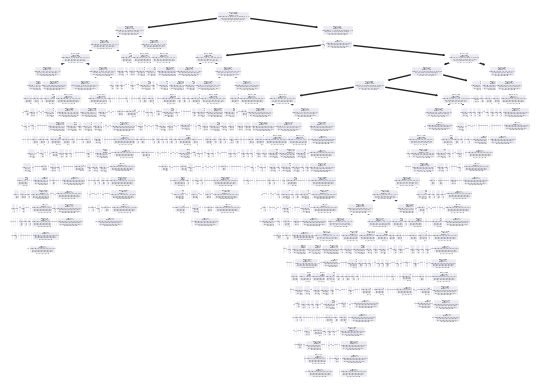

In [63]:
from sklearn import tree

tree.plot_tree(clf)

C:\Users\minhk\AppData\Local\Temp\ipykernel_30544\4103998404.py:32: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  majority = stats.mode(nearest_neighbours, axis=None).mode[0]


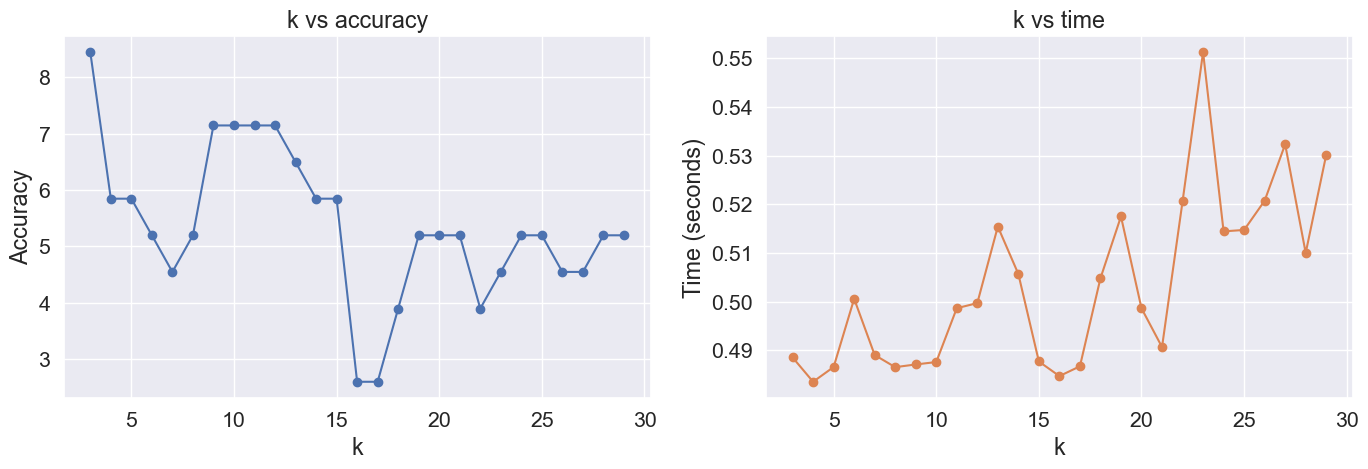

In [64]:
k_max = 30
accuracies = []
times = []

for k in range(3,k_max):
    clf = kNN(k=k, metric='euclidean')
    clf.fit(X_train.values, y_train.values)

    start = time.time()
    preds = clf.predict(X_test.values)
    stop = time.time()

    acc = accuracy(preds, y_test)
    accuracies.append(acc)
    times.append(stop-start)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(range(3,k_max), accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('k vs accuracy')

plt.subplot(1,2,2)
plt.plot(range(3,k_max), times, marker='o', c='C1')
plt.xlabel('k')
plt.ylabel('Time (seconds)')
plt.title('k vs time')
plt.tight_layout()
plt.show()

C:\Users\minhk\AppData\Local\Temp\ipykernel_30544\4103998404.py:32: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  majority = stats.mode(nearest_neighbours, axis=None).mode[0]


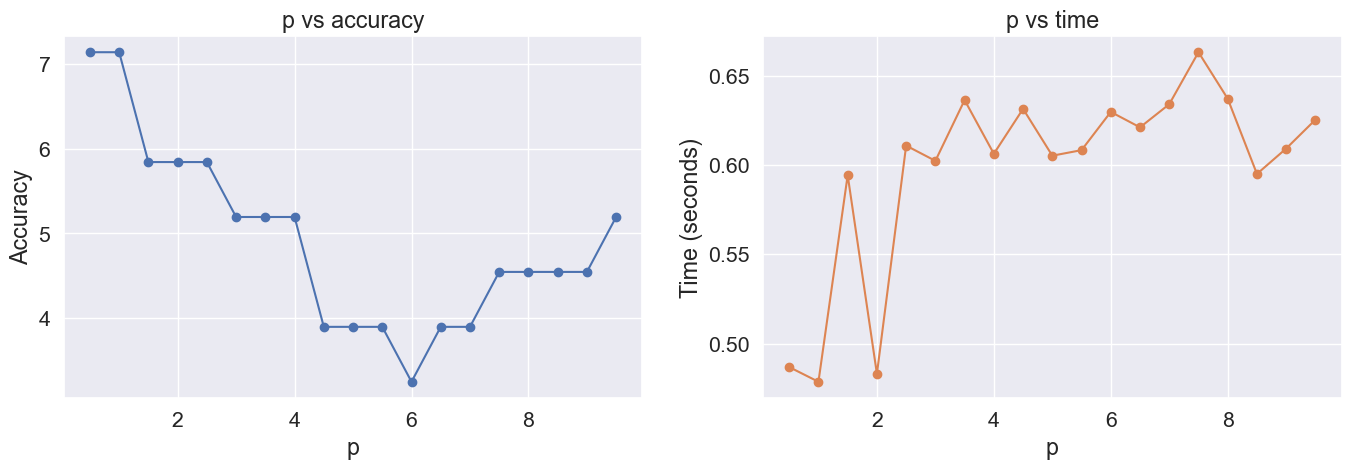

In [65]:
p_grid = np.arange(0.5,10,0.5)
accuracies = []
times = []

for p in p_grid:
    clf = kNN(k=5, metric='minkowski',p=p)
    clf.fit(X_train.values, y_train.values)

    start = time.time()
    preds = clf.predict(X_test.values)
    stop = time.time()

    acc = accuracy(preds, y_test)
    accuracies.append(acc)
    times.append(stop-start)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(p_grid, accuracies, marker='o')
plt.xlabel('p')
plt.ylabel('Accuracy')
plt.title('p vs accuracy')

plt.subplot(1,2,2)
plt.plot(p_grid, times, marker='o', c='C1')
plt.xlabel('p')
plt.ylabel('Time (seconds)')
plt.title('p vs time')
plt.tight_layout()
plt.show()